# Assignment Five

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import trapezoid


## Problem One: Mapping the Vector Field (Ey, Ez)


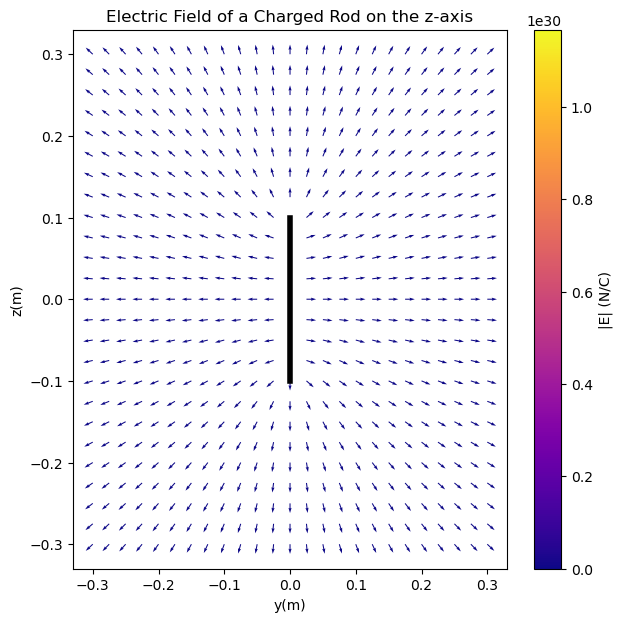

In [2]:
#constants 

k_coulomb = 8.99e9  # N m^2 / C^2


def calculate_electric_field(y_obs, z_obs, L=0.2, lam=1e-9):
    
    

    # Discretize the rod
    n_segments = 1000
    z_rod = np.linspace(-L/2, L/2, n_segments)

    # Distance r from each rod element to observation point
    r = np.sqrt(y_obs**2 + (z_obs - z_rod)**2) + 1e-20

    # Electric field integrands
    Ey_integrand = y_obs / r**3
    Ez_integrand = (z_obs - z_rod) / r**3

    # Integrate using trapezoid rule
    Ey = k_coulomb * lam * trapezoid(Ey_integrand, z_rod)
    Ez = k_coulomb * lam * trapezoid(Ez_integrand, z_rod)

    return Ey, Ez
 
 
 
#points of observation
y_vals = np.linspace(-0.3, 0.3, 25)
z_vals = np.linspace(-0.3, 0.3, 25)
Y, Z = np.meshgrid(y_vals, z_vals) 

Ey_grid = np.zeros_like(Y) 
Ez_grid = np.zeros_like(Z) 

#Fied at each point 
for i in range (Y.shape[0]):
    for j in range (Y.shape[1]):
       Ey_grid[i, j], Ez_grid[i, j] = calculate_electric_field(
          Y[i, j], Z[i, j], L = 0.2, lam = 1e-9)




# Field magnitude
E_mag = np.sqrt(Ey_grid**2 + Ez_grid**2) 
E_mag[E_mag == 0] = 1e-20

# Normalize vectors for quiver
Ey_norm = Ey_grid / E_mag
Ez_norm = Ez_grid / E_mag

# Plot
plt.figure(figsize=(7, 7))
plt.quiver(Y, Z, Ey_norm, Ez_norm, E_mag, cmap='plasma')
plt.colorbar(label='|E| (N/C)')
plt.title("Electric Field of a Charged Rod on the z-axis")
plt.xlabel("y(m)")
plt.ylabel("z(m)")

# Draw the rod
plt.plot([0, 0], [-0.1, 0.1], 'k-', linewidth=4)

plt.show()

    



## Task Two Protons vs. Electrons (Dynamics) 

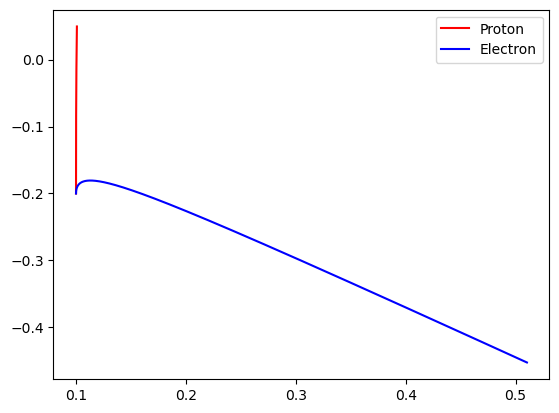

In [3]:
from scipy.integrate import solve_ivp 

#particles  
q_e = 1.602e-19     #electron charge 
m_e = 9.11e-31      #electron mass 
q_p = 1.602e-19     #proton charge
m_p = 1.67e-27      #proton mass

def particle_ode(t, state, q, m): 
    y, z, vy, vz = state
    Ey, Ez = calculate_electric_field(y, z) 

    ay = (q/m) * Ey
    az = (q/m) * Ez
    return [vy, vz, ay, az]

#conditions 

y0 = 0.1 
z0 = -0.2 
vy0 = 0.0 
vz0 = 5e5 

state0 = [y0, z0, vy0, vz0] 

t_span = (0, 5e-7)      #sim time
t_eval = np.linspace(t_span[0], t_span[1], 2000) 

#solving for proton 
sol_p = solve_ivp(particle_ode, t_span, state0, t_eval=t_eval, args=(q_p, m_p)) 

#solving for electron 
sol_e = solve_ivp(particle_ode, t_span, state0, t_eval=t_eval, args=(q_e, m_e)) 

#plottttt
plt.plot(sol_p.y[0], sol_p.y[1], 'r-', label='Proton')

# Electron path
plt.plot(sol_e.y[0], sol_e.y[1], 'b-', label='Electron')

plt.legend()
plt.show()


<span style='background: #f3a1d8a8'>Due to the mass of the proton the acceleration is slower than the electron which mass is vastly smaller</span>

## Task Three: Verification (The Two Limits) 


In [4]:
#charge limit test 
y_test = 5.0 
z_test = 0 

Ey_num, Ez_num = calculate_electric_field(y_test, z_test, L = 0.2, lam = 1e-9) 

#result 
Q = 1e-9 * 0.2 
Ey_point = k_coulomb * Q / (y_test**2)

print("Numerical Ey", Ey_num)
print("Point Charge Ey =", Ey_point)
print("Difference =", 100 * abs(Ey_num - Ey_point) / Ey_point) 

Numerical Ey 0.07190562028496529
Point Charge Ey = 0.07192000000000001
Difference = 0.019994042039378192


In [5]:
#Infinate limit test 
y_test = 0.001
z_test = 0.0  

Ey_num, Ez_num = calculate_electric_field(y_test, z_test, L = 0.2, lam = 1e-9) 

#result 
Ey_inf = 2 * k_coulomb * 1e-9 / y_test  

print("Numerical Ey =", Ey_num)
print("Infinite line Ey =", Ey_inf)
print("Percent difference =", 100 * abs(Ey_num - Ey_inf) / Ey_inf)


Numerical Ey = 17979.101065612245
Infinite line Ey = 17980.0
Percent difference = 0.004999635082061775


## Task Four: 

In [6]:
k_coulomb = 8.99e9
lam = 1e-9          
L = 0.2


def calculate_electric_field_segments(y_obs, z_obs, L, lam, n_segments):
    z_rod = np.linspace(-L/2, L/2, n_segments) 
    r = np.sqrt(y_obs**2 + (z_obs - z_rod)**2) + 1e-20

    Ey_integrand = y_obs / r**3
    Ez_integrand = (z_obs - z_rod) / r**3

    Ey = k_coulomb * lam *trapezoid(Ey_integrand, z_rod)
    Ez = k_coulomb * lam *trapezoid(Ez_integrand, z_rod)
    return Ey, Ez 

#infinite line test 
y_test = 0.001
z_test = 0.0 

#result 
Ey_inf = 2 * k_coulomb * lam / y_test
print("Infinite Line Ey =", Ey_inf) 
print() 

segment_list = [50, 100, 200, 300, 500, 800, 1000, 1500, 2000] 

for n in segment_list:
    Ey_num, _ = calculate_electric_field_segments(y_test, z_test, L, lam, n)
    error = abs(Ey_num - Ey_inf) / Ey_inf * 100
    print(f"Segments = {n:4d} | Numerical Ey = {Ey_num:.4e} | Error = {error:.3f}%")



Infinite Line Ey = 17980.0

Segments =   50 | Numerical Ey = 6.6848e+03 | Error = 62.821%
Segments =  100 | Numerical Ey = 1.4266e+04 | Error = 20.656%
Segments =  200 | Numerical Ey = 1.7750e+04 | Error = 1.279%
Segments =  300 | Numerical Ey = 1.7967e+04 | Error = 0.071%
Segments =  500 | Numerical Ey = 1.7979e+04 | Error = 0.005%
Segments =  800 | Numerical Ey = 1.7979e+04 | Error = 0.005%
Segments = 1000 | Numerical Ey = 1.7979e+04 | Error = 0.005%
Segments = 1500 | Numerical Ey = 1.7979e+04 | Error = 0.005%
Segments = 2000 | Numerical Ey = 1.7979e+04 | Error = 0.005%


<span style='background: #6f99f3a8'>1. Because this is in the Z plane it does not effect the charge distribution 
2. There is a dramatic drop between 100 & 200, then the percentage is less than 1 are 300 and greater</span>

## Task Five

In [ ]:


#taken from task two 
m_p = 1.67e-27
q_p = 1.602e-19

#starting positions 
y0 = 0.0 
z0 = -0.3

vy0 = 0.0 
vz0 = 5e5 

def calculate_electric_field(y, z):
    Ey = .07192000000000001
    Ez = 1e5
    return Ey, Ez

#taken from task two 
def proton_equ(t, state, q, m): 
    y, z, vy, vz = state
    Ey, Ez = calculate_electric_field(y, z) 

    ay = q * Ey / m
    az = q * Ez / m
    return [vy, vz, ay, az]

def max_y_for_v(vz0):
    state0 =[y0, z0, 0.0, vz0] 
    sol = solve_ivp(
        proton_equ, (0, 5e-6),
        y0=state0,
        max_step = 1e-8,
        args=(q_p, m_p)
    )
    return np.max(sol.y[0]

def min_v():
    low, high = 1e3, 2e6 
    for _ in range (40):
         mid = 0.5 *(low + high)
         ymax = max_y_for_v(mid) 
         if ymax < 0.15:
             high = mid 
         else:
            low = mid 

    return high

v_min = min_v()
print("Minimum safe velocity:", v_min, "m/s")

Minimum safe velocity: 1000.0000018180799 m/s


## Task Six

In [7]:
from scipy.integrate import solve_ivp
import numpy as np

# your functions here...

m_p = 1.67e-27
q_p = 1.602e-19
epsilon0 = 8.854e-12
#rod parms
lambda_A = +1e-8
lambda_B = -1e-8
rod_length = 0.20 
half_L = rod_length / 2
#rod positions
yA = +0.1
yB = -0.1
#initial 
y0 = 0.0 
z0 = -0.3
vy0 = 1e3       #the nudge 
vz0 = 5e5  

def electric_rod(y, z, y_rod, lam): 
    dy = y - y_rod 
    z_prime = np.linspace(-half_L, half_L, 400)
    dz = z - z_prime

    r = np.sqrt(dy**2 + dz**2)
    dE = (lam / (4 * np.pi * epsilon0))
    Ez = np.sum(dE * dz) * (z_prime[1] - z_prime[0])
    Ey = np.sum(dE * dy) * (z_prime[1] - z_prime[0])
    return Ey, Ez



def calculate_electric_field(y, z):
    EyA, EzA = electric_rod(y, z, yA, lambda_A) 
    EyB, EzB = electric_rod(y, z, yB, lambda_B) 
    return EyA + EyB, EzA + EzB

#taken from task two 
def proton_equ(t, state): 
    y, z, vy, vz = state
    Ey, Ez = calculate_electric_field(y, z) 

    ay = q_p * Ey / m_p
    az = q_p * Ez / m_p
    return [vy, vz, ay, az]

def run_trajectory(vz0, tmax = 6e-6):
    state0 =[y0, z0, vy0, vz0] 
    
    sol = solve_ivp(
        proton_equ,
        (0, tmax),
        state0,
        max_step = 1e-8,
        dense_output=False,
        
    )
    return sol

def slingshot(sol):
    y_vals = sol.y[0]
    z_vals = sol.y[1]

    # looking for a sign change 
    schange = np.any(y_vals > 0) and np.any(y_vals < 0) 
    near_center = np.min(np.abs(z_vals)) < 0.05
    return schange and near_center



def slingshot_v(vmin = 1e4, vmax = 5e6, steps = 40):
    low, high = vmin, vmax
    
    for _ in range(steps):
         mid = 0.5 *(low + high)
         sol = run_trajectory(mid) 

         if slingshot(sol):
             high = mid
         else:
             low = mid 

    return high

v_sling = slingshot_v()
print("Slingshot velocity:", v_sling, "m/s")

Slingshot velocity: 5000000.0 m/s
